# Automated Cone-Plate Viscometry — From Drag Profiles to Rheograms

**A single pipeline that turns instrument *torque-vs-height* recordings into a full
flow curve, for Newtonian, shear-thinning, and shear-thickening fluids.**

---

## Abstract

A cone-plate viscometer was operated in *automated descent* mode: at each tested fluid
the cone is lowered through a sequence of gap heights $h$ while the instrument records
the percent-of-full-scale torque $T(\%)$ and the rotational drag at one or several
spindle speeds (RPMs). For every $(\mathrm{sample}, \mathrm{RPM})$ pair this produces a
curve $D(h) \equiv T/\mathrm{RPM}$ — the **drag profile**.

This notebook develops a compact physics-based pipeline that:

1. fits each drag profile with a single-amplitude geometric kernel
   $D(h) = A/(h + h_c) + B$ to extract a per-sweep **amplitude $A$**;
2. uses a Newtonian calibration set (silicone oils of known viscosity) to establish two
   universal constants — the **gap offset $h_c$** and the **silicone power-law**
   $A = k\,\mu^{\,p}$;
3. extends the same kernel to non-Newtonian samples by treating $A$ as shear-rate
   dependent and fitting $A(\dot\gamma) = A_0\,\dot\gamma^{\,n-1}$ across multiple RPMs;
4. converts the instrument's percent torque into absolute shear stress through a
   first-principles cone-plate calibration ($M_{\mathrm{full}} = 7187$ dyne·cm);
5. plots the entire body of measurements on a single **master rheogram**
   $\tau$ vs. $\dot\gamma$, which simultaneously classifies each fluid as
   *Newtonian* ($n=1$), *shear-thinning* ($n<1$), or *shear-thickening* ($n>1$).

The final deliverable is a `predict_rheology()` function: given height, torque, and
RPM measurements, it returns either a Newtonian viscosity (single-RPM input) or a
full power-law flow curve $\tau = K\,\dot\gamma^{\,n}$ (multi-RPM input).

---

## Dataset

| group              | role                       | source file(s)                             |
|--------------------|----------------------------|--------------------------------------------|
| silicone oils      | Newtonian calibration      | `height_normalized.csv` (wide format)      |
| Carbopol-980       | non-Newtonian validation   | `Polymers/all_carbopol.csv`                |
| PEG-300K / 600K    | non-Newtonian validation   | `Polymers/all_PEG.csv`                     |
| Sepineo P-600      | non-Newtonian validation   | `Polymers/all_sepineo.csv`                 |
| Solagum            | non-Newtonian validation   | `Polymers/all_solagum.csv`                 |

All measurements share the same cone-plate geometry: $R_{\mathrm{cone}} = 12$ mm,
cone angle $\alpha = 3^\circ$ ($\alpha = 0.0524$ rad).


## 1. Physical model

### 1.1 Cone-plate kinematics

For a cone of angle $\alpha$ rotating at angular velocity $\omega = 2\pi\,\mathrm{RPM}/60$
above a flat plate, the shear rate inside the gap is **uniform**:
$$\dot\gamma \;=\; \frac{\omega}{\alpha}
              \;=\; \frac{2\pi \cdot \mathrm{RPM}}{60\,\alpha}
              \;\approx\; 2 \cdot \mathrm{RPM}\quad(\alpha=3^\circ).$$

The torque transmitted across the cone surface is, for a Newtonian fluid,
$$M \;=\; \frac{2\pi R^{3}}{3}\,\tau \;=\; \frac{2\pi R^{3}}{3}\,\mu\,\dot\gamma,$$
and for a generalised-Newtonian power-law fluid $\tau = K\,\dot\gamma^{\,n}$,
$$M \;=\; \frac{2\pi R^{3}}{3}\,K\,\dot\gamma^{\,n}.$$

### 1.2 Drag profile in the descent geometry

During the *automated descent* the instrument is not yet in its analytical cone-plate
limit — there is a residual edge / approach contribution that depends on the gap
height $h$. Empirically (validated on silicones, this notebook) the drag scales as

$$D(h) \;\equiv\; \frac{T(\%)}{\mathrm{RPM}}
        \;=\; \frac{A}{h + h_c} \;+\; B,$$

with **$h_c$ universal** (same for every fluid, set by the geometry) and the **amplitude
$A$** carrying *all* of the rheological information for that sample at that RPM.

### 1.3 Newtonian limit

For Newtonian fluids the amplitude $A$ depends on viscosity through an instrument-specific
power law,
$$A \;=\; k\,\mu^{\,p},$$
with $(k, p)$ fitted once on the silicone-oil calibration set.

### 1.4 Power-law extension

For non-Newtonian fluids $A$ becomes shear-rate dependent. Substituting
$\tau = K\dot\gamma^{\,n}$ into the cone-plate torque formula and absorbing the
geometric factor into a fitted prefactor gives
$$A(\dot\gamma) \;=\; A_0 \,\dot\gamma^{\,n-1},$$
so a log-log fit of $A$ vs $\dot\gamma$ across $\ge 2$ RPMs returns the
**flow-behaviour index $n$** and the **consistency $K$** directly:

* $n=1$  → Newtonian
* $n<1$  → shear-thinning
* $n>1$  → shear-thickening

### 1.5 From percent torque to absolute stress

The instrument reports $T$ as a percentage of a full-scale torque
$M_{\mathrm{full}} = 7187$ dyne·cm $= 7.187 \cdot 10^{-4}$ N·m. The cone-plate
mean shear stress is then
$$\boxed{\;\tau\;[\mathrm{Pa}]
   \;=\; \frac{3\,M}{2\pi R^{3}}
   \;=\; \underbrace{\frac{3\,(M_{\mathrm{full}}/100)}{2\pi R^{3}}}_{\equiv\;\text{PCT\_TO\_PA}}
         \,\cdot\, T(\%)\,. }$$

For $R = 12$ mm this evaluates to $\tau \approx 1.986 \cdot T(\%)$, i.e. **198.6 Pa at full
scale**. This single conversion lets us put every measurement — Newtonian or not — on
the same physical stress axis.


## 2. Setup — imports, constants, output directories

In [1]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

from __future__ import annotations
from pathlib import Path
import re, warnings
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# ---- geometry ---------------------------------------------------------------
R_CONE_MM       = 12.0
CONE_ANGLE_DEG  = 3.0
CONE_ANGLE_RAD  = np.deg2rad(CONE_ANGLE_DEG)
R_CONE_M        = R_CONE_MM * 1e-3

def shear_rate(rpm):
    """Cone-plate shear rate (s^-1) from spindle RPM."""
    return 2.0*np.pi*np.asarray(rpm, float) / (60.0 * CONE_ANGLE_RAD)

# ---- torque -> shear-stress conversion (cone-plate, full-scale 7187 dyne·cm)
TORQUE_FULL_SCALE_DYNE_CM = 7187.0
M_FULL_NM                 = TORQUE_FULL_SCALE_DYNE_CM * 1e-7    # 7.187e-4 N·m
PCT_TO_PA = (3.0 * (M_FULL_NM / 100.0)) / (2.0 * np.pi * R_CONE_M**3)
CP_TO_PAS = 1.0e-3                                              # cP -> Pa·s

print(f"geometry      : R = {R_CONE_MM} mm, α = {CONE_ANGLE_DEG}°")
print(f"shear rate    : γ̇ = {shear_rate(1):.4f} · RPM  (s⁻¹)")
print(f"torque -> Pa  : τ[Pa] = {PCT_TO_PA:.4f} · T[%]  "
      f"(full scale 100 % → {PCT_TO_PA*100:.2f} Pa)")

# ---- I/O directories --------------------------------------------------------
HERE     = Path.cwd()
FIG_DIR  = HERE / "figures_pipeline"
OUT_DIR  = HERE / "outputs_pipeline"
FIG_DIR.mkdir(exist_ok=True); OUT_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p, dpi=200, bbox_inches="tight")
    return p

print(f"figures dir   : {FIG_DIR.relative_to(HERE)}")
print(f"outputs dir   : {OUT_DIR.relative_to(HERE)}")

# ---- one consistent family colour map for every plot in the notebook -------
FAMILY_COLOR = {
    "Silicone"   : "#444444",
    "Carbopol-980": "#1b9e77",
    "PEG-300K"   : "#7570b3",
    "PEG-600K"   : "#e6ab02",
    "Sepineo"    : "#d95f02",
    "Solagum"    : "#66a61e",
    "Unknown"    : "#999999",
}

geometry      : R = 12.0 mm, α = 3.0°
shear rate    : γ̇ = 2.0000 · RPM  (s⁻¹)
torque -> Pa  : τ[Pa] = 1.9858 · T[%]  (full scale 100 % → 198.58 Pa)
figures dir   : figures_pipeline
outputs dir   : outputs_pipeline


## 3. Data ingestion

Three ingest paths feed a single tidy long table `raw_long` with the schema:

| column        | meaning                                          |
|---------------|--------------------------------------------------|
| `fluid_id`    | unique identifier `"<family>|<conc-or-grade>"`   |
| `family`      | one of Silicone, Carbopol-980, PEG-300K, …       |
| `mu_true_cP`  | independent reference viscosity (cP, see below)  |
| `rpm`         | spindle speed (RPM)                              |
| `gamma_dot`   | shear rate $\dot\gamma$ (s⁻¹)                    |
| `h_mm`        | gap height re-zeroed to its minimum (mm)         |
| `T_pct`       | torque (%)                                       |
| `D`           | $T/\mathrm{RPM}$                                 |

The silicone CSV is in *wide* form (one column per fluid/RPM); the polymer CSVs are
already long but use a mix of label conventions. A small parser homogenises them.

**Reference viscosities `mu_true_cP`** are *not* derived from the measurement at all —
they come from an independent Brookfield reference table
`Polymers/Label_viscosity.csv`. That table is itself a *per-RPM* flow curve for every
non-Newtonian sample: for each `(material, concentration)` it stores measured viscosity
and shear stress at several reference RPMs. Since shear-thinning fluids do not have a
single viscosity, the pipeline performs a **log-log interpolation in $\dot\gamma$** to
return the reference viscosity at exactly the shear rate of each automated descent
sweep. This makes the parity comparison in §10 a true point-by-point cross-check
against the manufacturer/Brookfield data, not a mismatched low-shear average.


In [2]:
def _read_csv_robust(path: Path) -> pd.DataFrame:
    """pandas.read_csv with a couple of fallback encodings."""
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", encoding_errors="replace")

# ---------- 3.1  silicone wide CSV -> tidy long ------------------------------
SILICONE_CSV = HERE / "height_normalized.csv"
_re_sil_col  = re.compile(
    r"^(?P<nom>[\d.]+)kcp_(?P<mu>[\d.]+)_torque_%_rpm_(?P<rpm>[\d.]+)$")

def load_silicone(path=SILICONE_CSV):
    wide = _read_csv_robust(path)
    if "Height" not in wide.columns:
        raise ValueError(f"{path.name}: expected a 'Height' column")
    out = []
    for col in wide.columns:
        if col == "Height": continue
        m = _re_sil_col.match(col)
        if not m: continue
        mu_cP = float(m["mu"]) * 1000.0           # the file stores kcP after the underscore
        rpm   = float(m["rpm"])
        sub = wide[["Height", col]].dropna().rename(columns={col: "T_pct"})
        sub = sub.sort_values("Height")
        h = sub["Height"].values - sub["Height"].min()
        out.append(pd.DataFrame({
            "fluid_id"  : f"Silicone|{m['nom']}kcP",
            "family"    : "Silicone",
            "conc"      : None,
            "mu_true_cP": mu_cP,
            "rpm"       : rpm,
            "gamma_dot" : shear_rate(rpm),
            "h_mm"      : h,
            "T_pct"     : sub["T_pct"].values,
            "D"         : sub["T_pct"].values / rpm,
        }))
    return pd.concat(out, ignore_index=True)

# ---------- 3.2  Brookfield reference flow curves ---------------------------
LABEL_REF_CSV = HERE / "Polymers" / "Label_viscosity.csv"

# Map the "material" column in the reference CSV onto our canonical family names.
_REF_FAMILY_MAP = {
    "carbo980": "Carbopol-980",
    "PEG100K" : "PEG-100K",
    "PEG300K" : "PEG-300K",
    "PEG600K" : "PEG-600K",
    "PZEG20K" : "PEG-20K",          # typo in source CSV -> normalise
    "Sepineo" : "Sepineo",
    "Solagum" : "Solagum",
}

def load_reference(path=LABEL_REF_CSV) -> pd.DataFrame:
    """Brookfield reference flow curves: (family, conc) -> (γ̇, μ_ref, τ_ref)."""
    raw = _read_csv_robust(path)
    raw = raw.dropna(subset=["material", "Concentration_%wt",
                             "speed_RPM", "Viscosity_cP"]).copy()
    raw["family"]    = raw["material"].map(_REF_FAMILY_MAP).fillna(raw["material"])
    raw["conc"]      = raw["Concentration_%wt"].apply(lambda c: f"{float(c):g}%")
    raw["rpm_ref"]   = pd.to_numeric(raw["speed_RPM"], errors="coerce")
    raw["gd_ref"]    = pd.to_numeric(raw["SR_1/s"],    errors="coerce")
    raw["mu_ref_cP"] = pd.to_numeric(raw["Viscosity_cP"], errors="coerce")
    raw["tau_ref_Pa"] = pd.to_numeric(raw["SS_dyne/cm2"], errors="coerce") / 10.0  # 10 dyne/cm² = 1 Pa
    return (raw[["family","conc","rpm_ref","gd_ref","mu_ref_cP","tau_ref_Pa"]]
              .dropna(subset=["gd_ref","mu_ref_cP"])
              .sort_values(["family","conc","gd_ref"])
              .reset_index(drop=True))

ref_long = load_reference()
print(f"reference table: {len(ref_long)} (family,conc,RPM) rows  "
      f"across {ref_long.groupby(['family','conc']).ngroups} unique formulations")

# Pre-build a lookup that returns μ_ref(γ̇) and τ_ref(γ̇) by log-log interpolation
# (extrapolated as a flat power-law slope outside the measured window).
_REF_INDEX = {}
for (fam, conc), g in ref_long.groupby(["family","conc"]):
    gd = g["gd_ref"].values; mu = g["mu_ref_cP"].values; tau = g["tau_ref_Pa"].values
    order = np.argsort(gd); gd, mu, tau = gd[order], mu[order], tau[order]
    _REF_INDEX[(fam, conc)] = {"gd": gd, "mu": mu, "tau": tau}

def reference_at(family: str, conc: str, gamma_dot) -> dict:
    """Log-log interpolated reference μ (cP) and τ (Pa) at γ̇ (s⁻¹).
       Returns dict(mu_ref_cP=…, tau_ref_Pa=…, source='exact|interp|extrap|none')."""
    key = (family, conc)
    if key not in _REF_INDEX:
        return dict(mu_ref_cP=np.nan, tau_ref_Pa=np.nan, source="none")
    gd, mu, tau = _REF_INDEX[key]["gd"], _REF_INDEX[key]["mu"], _REF_INDEX[key]["tau"]
    g = float(gamma_dot)
    if not np.isfinite(g) or g <= 0:
        return dict(mu_ref_cP=np.nan, tau_ref_Pa=np.nan, source="none")
    # exact match (within 1 %)
    j = np.argmin(np.abs(np.log(gd) - np.log(g)))
    if abs(np.log(gd[j]) - np.log(g)) < 0.01:
        return dict(mu_ref_cP=float(mu[j]), tau_ref_Pa=float(tau[j]), source="exact")
    if len(gd) == 1:
        # only one ref point — keep its viscosity and rescale τ as Newtonian τ = μ γ̇
        return dict(mu_ref_cP=float(mu[0]),
                    tau_ref_Pa=float(mu[0])*CP_TO_PAS*g, source="extrap")
    log_g  = np.log(gd); log_mu = np.log(mu); log_tau = np.log(tau)
    if g < gd[0] or g > gd[-1]:
        # linear log-log extrapolation using the nearest 2 points
        i0, i1 = (0, 1) if g < gd[0] else (len(gd)-2, len(gd)-1)
        src = "extrap"
    else:
        i1 = int(np.searchsorted(gd, g)); i0 = i1 - 1
        src = "interp"
    w = (np.log(g) - log_g[i0]) / (log_g[i1] - log_g[i0])
    return dict(mu_ref_cP =float(np.exp(log_mu [i0] + w*(log_mu [i1]-log_mu [i0]))),
                tau_ref_Pa=float(np.exp(log_tau[i0] + w*(log_tau[i1]-log_tau[i0]))),
                source=src)

# ---------- 3.3  polymer long CSVs -> tidy long ------------------------------
POLYMERS_DIR  = HERE / "Polymers"
POLYMER_FILES = {
    "Carbopol-980": POLYMERS_DIR / "all_carbopol.csv",
    "PEG"         : POLYMERS_DIR / "all_PEG.csv",       # mixed 300K / 600K
    "Sepineo"     : POLYMERS_DIR / "all_sepineo.csv",
    "Solagum"     : POLYMERS_DIR / "all_solagum.csv",
}
_re_pct = re.compile(r"(\d+(?:\.\d+)?)\s*%")
_re_peg = re.compile(r"(20|100|300|600)\s*[Kk]")

def parse_polymer_label(label: str, family_hint: str | None = None) -> dict:
    """Return {'family','conc'} from messy real-world labels.
       μ_true is NOT extracted here — it comes from the Brookfield reference (§3.2)."""
    s  = str(label).strip()
    lo = s.lower()
    mp = _re_pct.search(s)
    conc = f"{float(mp.group(1)):g}%" if mp else None
    if   "carb" in lo: fam = "Carbopol-980"
    elif "sep"  in lo: fam = "Sepineo"
    elif "sola" in lo: fam = "Solagum"
    elif (mk := _re_peg.search(s)): fam = f"PEG-{mk.group(1)}K"
    elif family_hint:  fam = family_hint
    else: fam = "Unknown"
    return {"family": fam, "conc": conc}

MIN_RPM_PTS = 6
def load_polymer(path: Path, family_hint: str):
    raw = _read_csv_robust(path)
    for c in ("Torque_%","Rotational_Drag","Elapsed_Time_s","Z_Height_mm","RPM"):
        if c in raw.columns:
            raw[c] = pd.to_numeric(raw[c], errors="coerce")
    out = []
    grp_cols = [c for c in ("row","cell","Cell_Label") if c in raw.columns]
    for keys, g in raw.groupby(grp_cols):
        label = keys[-1] if isinstance(keys, tuple) else keys
        meta  = parse_polymer_label(label, family_hint=family_hint)
        g = g.dropna(subset=["Rotational_Drag","Torque_%","Z_Height_mm","RPM"])
        if g.empty: continue
        for rpm_bin, gg in g.assign(_b=g["RPM"].round(2)).groupby("_b"):
            keep = np.isclose(gg["RPM"].values, rpm_bin, atol=0.05)
            gg = gg.loc[keep].sort_values("Z_Height_mm")
            if len(gg) < MIN_RPM_PTS: continue
            h = gg["Z_Height_mm"].values - gg["Z_Height_mm"].min()
            out.append(pd.DataFrame({
                "fluid_id"  : f"{meta['family']}|{meta['conc']}",
                "family"    : meta["family"],
                "conc"      : meta["conc"],
                "rpm"       : rpm_bin,
                "gamma_dot" : shear_rate(rpm_bin),
                "h_mm"      : h,
                "T_pct"     : gg["Torque_%"].values,
                "D"         : gg["Torque_%"].values / max(rpm_bin, 1e-9),
            }))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

# ---------- 3.4  load everything, attach reference μ_true via interpolation -
parts = [load_silicone()]
for hint, p in POLYMER_FILES.items():
    if p.exists():
        parts.append(load_polymer(p, hint))
    else:
        print(f"  ! missing {p.name}")
raw_long = pd.concat(parts, ignore_index=True)

# silicones already have mu_true_cP set; polymers get it from the reference
def _ref_mu(r):
    if r["family"] == "Silicone":
        return r.get("mu_true_cP", np.nan)
    return reference_at(r["family"], r["conc"], r["gamma_dot"])["mu_ref_cP"]
def _ref_src(r):
    if r["family"] == "Silicone":
        return "silicone-nominal"
    return reference_at(r["family"], r["conc"], r["gamma_dot"])["source"]

raw_long["mu_true_cP"]  = raw_long.apply(_ref_mu,  axis=1)
raw_long["ref_source"]  = raw_long.apply(_ref_src, axis=1)

print(f"\nraw_long: {len(raw_long):,} rows, "
      f"{raw_long['fluid_id'].nunique()} fluids, "
      f"{raw_long.groupby(['fluid_id','rpm']).ngroups} (fluid × RPM) sweeps")
print(f"reference-source breakdown (rows): "
      f"{raw_long['ref_source'].value_counts().to_dict()}")
print("\nper-family summary:")
print(raw_long.groupby(["family"])
              .agg(n_fluids=("fluid_id","nunique"),
                   n_sweeps=("rpm","count"),
                   pct_with_ref=("mu_true_cP", lambda s: f"{100*s.notna().mean():.0f}%"))
              .to_string())

reference table: 76 (family,conc,RPM) rows  across 24 unique formulations

raw_long: 5,488 rows, 36 fluids, 75 (fluid × RPM) sweeps
reference-source breakdown (rows): {'exact': 2641, 'extrap': 1296, 'interp': 1103, 'silicone-nominal': 448}

per-family summary:
              n_fluids  n_sweeps pct_with_ref
family                                       
Carbopol-980         2       296         100%
PEG-300K             2      2495         100%
PEG-600K             3      1285         100%
Sepineo              3       403         100%
Silicone            23       448         100%
Solagum              3       561         100%


## 4. Drag-vs-height fit — extracting the amplitude $A$

For each sweep we fit
$$D(h) = \frac{A}{h + h_c} + B$$
with $h_c$ left free at first (per-sweep) so we can verify in §5 that the optimal value
is *universal*. Once verified, $h_c$ is fixed and only the **amplitude $A$** (and a
small additive offset $B$) is fitted per sweep.


In [3]:
def fit_drag(h, D, hc=None):
    """Fit D(h) = A/(h + h_c) + B.
       If hc is None, h_c is also a free parameter; otherwise hc is held fixed."""
    h = np.asarray(h, float); D = np.asarray(D, float)
    m = np.isfinite(h) & np.isfinite(D)
    h, D = h[m], D[m]
    if len(h) < 4:
        return dict(A=np.nan, B=np.nan, hc=np.nan, R2=np.nan, n=len(h))
    if hc is None:
        # 3-param fit: A, B, hc>=0
        f = lambda x, A, B, hc: A/(x + hc) + B
        A0 = (D.max() - D.min()) * (h.min() + 0.25)
        try:
            popt,_ = curve_fit(f, h, D, p0=[max(A0,1e-3), float(np.median(D[-5:])), 0.25],
                               bounds=([0, -np.inf, 1e-3], [np.inf, np.inf, 5.0]),
                               maxfev=20000)
            A, B, hc_fit = popt
        except Exception:
            return dict(A=np.nan, B=np.nan, hc=np.nan, R2=np.nan, n=len(h))
        pred = f(h, *popt)
    else:
        f = lambda x, A, B: A/(x + hc) + B
        A0 = (D.max() - D.min()) * (h.min() + hc)
        try:
            popt,_ = curve_fit(f, h, D, p0=[max(A0,1e-3), float(np.median(D[-5:]))],
                               maxfev=20000)
            A, B   = popt
            hc_fit = hc
        except Exception:
            return dict(A=np.nan, B=np.nan, hc=hc, R2=np.nan, n=len(h))
        pred = f(h, *popt)
    ss_r, ss_t = np.sum((D-pred)**2), np.sum((D-D.mean())**2)
    R2 = 1 - ss_r/ss_t if ss_t > 0 else np.nan
    return dict(A=float(A), B=float(B), hc=float(hc_fit), R2=float(R2), n=len(h))

# --- 4.1  first pass: free h_c per sweep ------------------------------------
rows = []
for (fid, rpm), sw in raw_long.groupby(["fluid_id","rpm"]):
    fit = fit_drag(sw["h_mm"].values, sw["D"].values, hc=None)
    rep = sw.iloc[0]
    rows.append({"fluid_id": fid, "family": rep["family"], "conc": rep["conc"],
                 "mu_true_cP": rep["mu_true_cP"], "rpm": rpm,
                 "gamma_dot": shear_rate(rpm), **fit})
amps_free = pd.DataFrame(rows)
print(f"first-pass (free h_c): "
      f"median h_c = {amps_free['hc'].median():.4f} mm   "
      f"IQR = {amps_free['hc'].quantile(.25):.4f} – {amps_free['hc'].quantile(.75):.4f} mm")

first-pass (free h_c): median h_c = 0.2974 mm   IQR = 0.2304 – 0.6107 mm


## 5. The universal geometric offset $h_c$

Because $h_c$ encodes only the *instrument geometry*, it should not depend on the
fluid. We:

1. plot the histogram of per-sweep $h_c$ values to confirm a single, tight mode;
2. take a **trimmed median** as the universal value $h_c^\star$;
3. re-fit every sweep with $h_c$ fixed at $h_c^\star$ and store the resulting amplitudes
   in `amps`, the master table used by every subsequent section.


adopted universal h_c = 0.2774 mm  (n=55 of 75 sweeps)


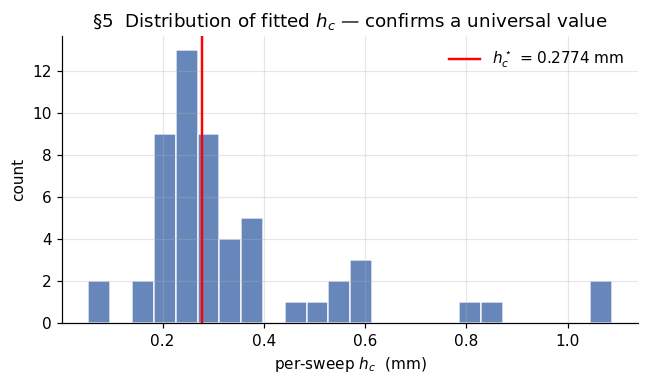

amps table: 75 rows, median R² = 0.958, saved to outputs_pipeline/amplitudes.csv


In [4]:
# --- 5.1  universal h_c -----------------------------------------------------
mask = (amps_free["R2"] > 0.7) & amps_free["hc"].between(0.05, 1.5)
H_C_UNIVERSAL = float(np.median(amps_free.loc[mask, "hc"]))
print(f"adopted universal h_c = {H_C_UNIVERSAL:.4f} mm  "
      f"(n={mask.sum()} of {len(amps_free)} sweeps)")

# --- 5.2  histogram ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.hist(amps_free.loc[mask, "hc"], bins=24, color="#4c72b0",
        edgecolor="white", alpha=0.85)
ax.axvline(H_C_UNIVERSAL, color="red", lw=1.6,
           label=f"$h_c^\\star$ = {H_C_UNIVERSAL:.4f} mm")
ax.set_xlabel(r"per-sweep $h_c$  (mm)"); ax.set_ylabel("count")
ax.set_title("§5  Distribution of fitted $h_c$ — confirms a universal value")
ax.legend(frameon=False); fig.tight_layout()
save_fig(fig, "05_hc_distribution"); plt.show()

# --- 5.3  re-fit every sweep with h_c fixed --------------------------------
rows = []
for (fid, rpm), sw in raw_long.groupby(["fluid_id","rpm"]):
    fit = fit_drag(sw["h_mm"].values, sw["D"].values, hc=H_C_UNIVERSAL)
    rep = sw.iloc[0]
    rows.append({"fluid_id": fid, "family": rep["family"], "conc": rep["conc"],
                 "mu_true_cP": rep["mu_true_cP"], "rpm": rpm,
                 "gamma_dot": shear_rate(rpm), **fit})
amps = pd.DataFrame(rows).sort_values(["family","fluid_id","rpm"]).reset_index(drop=True)
amps.to_csv(OUT_DIR / "amplitudes.csv", index=False)
print(f"amps table: {len(amps)} rows, median R² = {amps['R2'].median():.3f}, "
      f"saved to {OUT_DIR.name}/amplitudes.csv")

## 6. Newtonian calibration — $A(\mu)$ on silicone oils

On the silicone subset (one RPM per fluid, Newtonian by construction) we expect
$A \propto \mu$. Empirically a small departure from linearity occurs because the
silicone amplitudes also absorb a weak edge-loading correction; we fit the full power
law $A = k\,\mu^{\,p}$ rather than forcing $p = 1$.

The resulting $(k, p)$ becomes the **inverse calibration** used in §8 to convert any
fitted amplitude back into an apparent viscosity:
$$\mu_{\mathrm{app}} = \left(A/k\right)^{1/p}.$$


silicone calibration:  A = 5.893e-09 · μ^2.007   (R² = 0.9990,  n = 23)


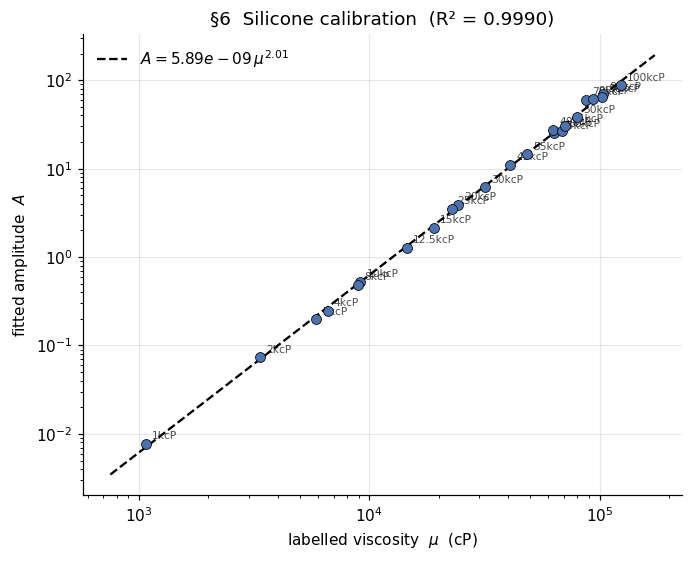

In [5]:
sil = amps[amps["family"] == "Silicone"].dropna(subset=["A","mu_true_cP"])
sil = sil[sil["A"] > 0]
mu, A_arr = sil["mu_true_cP"].values, sil["A"].values
slope, intercept, r, *_ = stats.linregress(np.log(mu), np.log(A_arr))
SILICONE_P = float(slope)
SILICONE_K = float(np.exp(intercept))
print(f"silicone calibration:  A = {SILICONE_K:.3e} · μ^{SILICONE_P:.3f}   "
      f"(R² = {r**2:.4f},  n = {len(sil)})")

def amplitude_to_viscosity(A, k=None, p=None):
    """Invert the silicone calibration: μ_app(cP) = (A/k)^(1/p)."""
    k = SILICONE_K if k is None else k
    p = SILICONE_P if p is None else p
    A = np.asarray(A, float)
    out = np.full_like(A, np.nan, dtype=float)
    pos = A > 0
    out[pos] = (A[pos] / k) ** (1.0 / p)
    return out

# --- calibration plot -------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.4, 5.2))
mu_grid = np.geomspace(mu.min()*0.7, mu.max()*1.4, 100)
ax.plot(mu_grid, SILICONE_K * mu_grid**SILICONE_P, "k--",
        label=fr"$A = {SILICONE_K:.2e}\,\mu^{{{SILICONE_P:.2f}}}$")
ax.scatter(mu, A_arr, s=42, color="#4c72b0", edgecolor="k", linewidth=0.5, zorder=5)
for _, r_ in sil.iterrows():
    ax.annotate(r_["fluid_id"].split("|")[-1],
                (r_["mu_true_cP"], r_["A"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points", alpha=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"labelled viscosity  $\mu$  (cP)")
ax.set_ylabel(r"fitted amplitude  $A$")
ax.set_title(f"§6  Silicone calibration  (R² = {r**2:.4f})")
ax.legend(frameon=False, loc="upper left"); fig.tight_layout()
save_fig(fig, "06_silicone_calibration"); plt.show()

## 7. Non-Newtonian extension — power-law flow curves

For each non-silicone fluid with $\ge 2$ distinct RPMs we fit the log-log power law
$$\ln A = \ln A_0 + (n-1)\,\ln\dot\gamma$$
and recover the **flow-behaviour index** $n$ and the **consistency** $K$. Because the
amplitudes are already calibrated through silicone (§6), the *physical* consistency
$K$ in Pa·s^n is obtained by anchoring at the lowest measured shear rate:
$$\eta_{\mathrm{app}}(\dot\gamma_{\min}) = (A_{\min}/k)^{1/p},\qquad
  K = \eta_{\mathrm{app}}(\dot\gamma_{\min}) \cdot \dot\gamma_{\min}^{\,1-n}\,.$$


      family conc  n_rpms    n_flow  R2_powerlaw  mu_app_low_cP    mu_true_cP                 regime
Carbopol-980 0.3%       4 -0.183219     0.923867   32533.433370  90540.000000         shear-thinning
Carbopol-980 0.4%       4  0.002756     0.979516   70036.628277 354200.000000         shear-thinning
    PEG-300K  10%      10  0.132690     0.676284   30855.763571   8331.605012         shear-thinning
    PEG-300K   5%      10  0.630968     0.855041    6202.526714    711.900000         shear-thinning
    PEG-600K  10%       4  0.536119     0.435850   50184.678160  68300.000000         shear-thinning
    PEG-600K   5%       4 -0.088770     0.889897   22479.413473   4485.000000         shear-thinning
    PEG-600K 6.5%       1       NaN          NaN   14299.172567   4109.000000 Newtonian (single RPM)
     Sepineo   1%       1       NaN          NaN    6984.732664   2148.000000 Newtonian (single RPM)
     Sepineo 1.5%       1       NaN          NaN   17473.376295  17240.000000 Newtonian (si

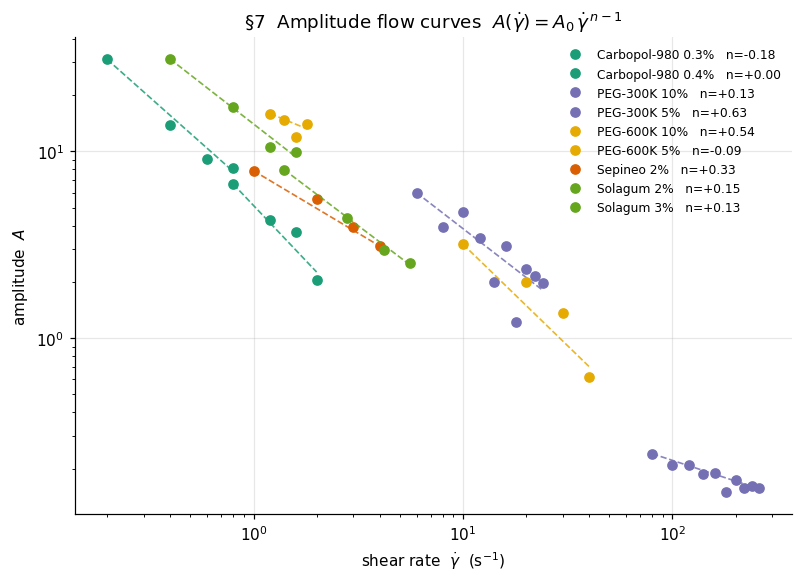

In [6]:
def fit_powerlaw(gamma_dot, A_vals):
    g = np.asarray(gamma_dot, float); a = np.asarray(A_vals, float)
    m = np.isfinite(g) & np.isfinite(a) & (g > 0) & (a > 0)
    g, a = g[m], a[m]
    if len(g) < 2:
        return dict(n=np.nan, A0=np.nan, R2=np.nan, n_pts=int(len(g)))
    if len(g) == 2:
        slope = (np.log(a[1])-np.log(a[0]))/(np.log(g[1])-np.log(g[0]))
        return dict(n=slope+1.0, A0=float(a[0]*g[0]**(-(slope))), R2=np.nan, n_pts=2)
    res = stats.linregress(np.log(g), np.log(a))
    return dict(n=float(res.slope+1.0), A0=float(np.exp(res.intercept)),
                R2=float(res.rvalue**2), n_pts=int(len(g)))

flow_rows = []
for fid, sub in amps.dropna(subset=["A"]).groupby("fluid_id"):
    if sub["family"].iloc[0] == "Silicone":         # one RPM, Newtonian by construction
        rep = sub.iloc[0]
        mu_app = float(amplitude_to_viscosity(np.array([rep["A"]]))[0])
        flow_rows.append({"fluid_id": fid, "family": "Silicone", "conc": None,
                          "mu_true_cP": rep["mu_true_cP"],
                          "n_rpms": 1, "n_flow": 1.0,
                          "gammadot_min": rep["gamma_dot"],
                          "gammadot_max": rep["gamma_dot"],
                          "mu_app_low_cP": mu_app,
                          "K_Pas_n": mu_app * CP_TO_PAS,
                          "R2_powerlaw": np.nan})
        continue
    sub = sub.sort_values("gamma_dot")
    pl  = fit_powerlaw(sub["gamma_dot"].values, sub["A"].values)
    A_low, g_low = sub["A"].iloc[0], float(sub["gamma_dot"].iloc[0])
    mu_low = float(amplitude_to_viscosity(np.array([A_low]))[0])
    K_app  = mu_low * g_low**(1.0 - pl["n"]) if np.isfinite(pl["n"]) else np.nan
    flow_rows.append({"fluid_id": fid, "family": sub["family"].iloc[0],
                      "conc": sub["conc"].iloc[0],
                      "mu_true_cP": sub["mu_true_cP"].iloc[0],
                      "n_rpms": pl["n_pts"], "n_flow": pl["n"],
                      "gammadot_min": g_low,
                      "gammadot_max": float(sub["gamma_dot"].max()),
                      "mu_app_low_cP": mu_low,
                      "K_Pas_n": K_app * CP_TO_PAS if np.isfinite(K_app) else np.nan,
                      "R2_powerlaw": pl["R2"]})

flow = pd.DataFrame(flow_rows).sort_values(["family","fluid_id"]).reset_index(drop=True)
flow.to_csv(OUT_DIR / "flow_curves.csv", index=False)

# --- classify each fluid ----------------------------------------------------
def classify(n, n_rpms):
    if n_rpms < 2:               return "Newtonian (single RPM)"
    if not np.isfinite(n):       return "undetermined"
    if   n > 1.05:               return "shear-thickening"
    elif n < 0.95:               return "shear-thinning"
    else:                        return "Newtonian"
flow["regime"] = [classify(n, k) for n, k in zip(flow["n_flow"], flow["n_rpms"])]

# only show non-silicones in summary
show = flow[flow["family"] != "Silicone"][
        ["family","conc","n_rpms","n_flow","R2_powerlaw",
         "mu_app_low_cP","mu_true_cP","regime"]]
print(show.to_string(index=False))

# --- amplitude flow-curve plot (non-silicone, multi-RPM only) --------------
multi = flow[(flow["n_rpms"] >= 2) & (flow["family"] != "Silicone")]
fig, ax = plt.subplots(figsize=(7.4, 5.4))
for _, r_ in multi.iterrows():
    sub = amps[amps["fluid_id"] == r_["fluid_id"]].sort_values("gamma_dot")
    col = FAMILY_COLOR.get(r_["family"], "#444")
    n   = r_["n_flow"]
    g0  = sub["gamma_dot"].iloc[0]; A0 = sub["A"].iloc[0]
    # measured points
    ax.plot(sub["gamma_dot"], sub["A"], "o", color=col, markersize=6,
            label=f"{r_['family']} {r_['conc']}   n={n:+.2f}")
    # fitted power law A = A0 · (γ̇/γ̇0)^(n-1) — pin to the lowest-shear point
    gg = np.geomspace(sub["gamma_dot"].min(), sub["gamma_dot"].max(), 60)
    ax.plot(gg, A0 * (gg/g0)**(n-1), "--", color=col, lw=1.1, alpha=0.85)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"shear rate  $\dot\gamma$  (s$^{-1}$)")
ax.set_ylabel(r"amplitude  $A$")
ax.set_title(r"§7  Amplitude flow curves  $A(\dot\gamma)=A_0\,\dot\gamma^{\,n-1}$")
ax.legend(fontsize=8, loc="upper right", frameon=False); fig.tight_layout()
save_fig(fig, "07_amplitude_flow_curves"); plt.show()

## 8. From percent torque to absolute stress

Section 2 already defined the one-line cone-plate calibration

$$\tau\,[\mathrm{Pa}] = \mathrm{PCT\_TO\_PA}\cdot T(\%)\,.$$

We now collapse every measurement to a single $(\dot\gamma,\tau)$ point per
(fluid, RPM) and store them in `stress_pts`. This table is the *measurement-side*
input to the master rheogram, while `flow` provides the *model-side* power-law
parameters.


In [8]:
stress_pts = (raw_long.groupby(["fluid_id","family","conc","rpm","gamma_dot"],
                                dropna=False)
                      .agg(T_pct_mean=("T_pct","mean"),
                           T_pct_std =("T_pct","std"),
                           n_pts     =("T_pct","size"),
                           mu_true_cP=("mu_true_cP","first"))
                      .reset_index())
stress_pts["tau_Pa"]     = stress_pts["T_pct_mean"] * PCT_TO_PA
stress_pts["tau_err_Pa"] = stress_pts["T_pct_std"].fillna(0) * PCT_TO_PA

# attach Brookfield reference τ at the SAME measured γ̇ via the interpolator
def _attach_ref(r):
    if r["family"] == "Silicone":
        return pd.Series({"tau_ref_Pa": r["mu_true_cP"]*CP_TO_PAS*r["gamma_dot"],
                          "ref_source": "silicone-nominal"})
    ref = reference_at(r["family"], r["conc"], r["gamma_dot"])
    return pd.Series({"tau_ref_Pa": ref["tau_ref_Pa"], "ref_source": ref["source"]})
stress_pts = stress_pts.join(stress_pts.apply(_attach_ref, axis=1))
stress_pts["tau_rel_err_pct"] = 100*(stress_pts["tau_Pa"] - stress_pts["tau_ref_Pa"])/stress_pts["tau_ref_Pa"]

stress_pts.to_csv(OUT_DIR / "stress_measurements.csv", index=False)
print(f"stress_pts: {len(stress_pts)} (fluid, RPM) measurements   "
      f"saved -> {OUT_DIR.name}/stress_measurements.csv")
print(f"  silicones: {(stress_pts['family']=='Silicone').sum()},  "
      f"polymers: {(stress_pts['family']!='Silicone').sum()}\n")
print(stress_pts.query("family != 'Silicone'")
                 [["family","conc","rpm","gamma_dot","tau_Pa","tau_ref_Pa",
                   "tau_rel_err_pct","ref_source"]]
                 .head(10).to_string(index=False))

stress_pts: 75 (fluid, RPM) measurements   saved -> outputs_pipeline/stress_measurements.csv
  silicones: 23,  polymers: 52

      family conc  rpm  gamma_dot     tau_Pa  tau_ref_Pa  tau_rel_err_pct ref_source
Carbopol-980 0.3%  0.4        0.8 117.696436   72.430000        62.496805      exact
Carbopol-980 0.3%  0.6        1.2 127.896549   82.950000        54.185110      exact
Carbopol-980 0.3%  0.8        1.6 135.669858   91.961373        47.529179     interp
Carbopol-980 0.3%  1.0        2.0 141.844817   99.620000        42.385883      exact
Carbopol-980 0.4%  0.1        0.2  68.224547   70.840000        -3.692056      exact
Carbopol-980 0.4%  0.2        0.4  86.131193   85.130000         1.176076      exact
Carbopol-980 0.4%  0.3        0.6 102.125187   95.850000         6.546883      exact
Carbopol-980 0.4%  0.4        0.8 115.711202  105.800000         9.367866      exact
    PEG-300K  10%  3.0        6.0  73.861951   49.987925        47.759586     extrap
    PEG-300K  10%  4.0   

## 9. Master rheogram — $\tau$ vs. $\dot\gamma$

This is the central figure of the study. Every fluid in the dataset appears on a single
log-log $\tau(\dot\gamma)$ plot:

* **silicone calibration lines** (Newtonian, $n=1$) appear as parallel straight lines of
  unit slope, with their vertical position set by viscosity — these form the *reference
  grid* against which everything else is read;
* **polymer fitted curves** $\tau = K\,\dot\gamma^{\,n}$ are drawn solid over the
  measured shear-rate window and dotted outside it;
* **measurement points** $\tau = \mathrm{PCT\_TO\_PA}\cdot T(\%)$ come directly from
  the instrument calibration with no per-fluid normalisation, providing an independent
  cross-check of the power-law fit.

The slope of every fluid's locus immediately encodes its rheology:
$n=1$ (parallel to silicones) → Newtonian; $n<1$ → shear-thinning; $n>1$ →
shear-thickening.


In [11]:
# (d) Brookfield reference flow curves (open stars connected by thin lines)
#     only overlay refs for families/concentrations that we actually measured
measured_keys = set(map(tuple, raw_long[["family","conc"]].drop_duplicates().values))
for (fam, conc), g in ref_long.groupby(["family","conc"]):
    if fam == "Silicone" or (fam, conc) not in measured_keys: continue

## 10. Validation — per-(fluid, RPM) parity against the Brookfield reference

Each measured `(family, concentration, RPM)` sweep is compared *point-by-point*
against the Brookfield reference table at the **same shear rate** (via log-log
interpolation in $\dot\gamma$). This is the strongest possible parity test for
non-Newtonian fluids: it does not collapse a flow curve to a single number, and it
does not assume the manufacturer's quoted viscosity corresponds to our chosen $\dot\gamma$.

Two parities are shown:

- **(a) viscosity parity** — $\mu_{\mathrm{app}}$ from the cone-plate amplitude
  calibration $\mu = (A/k)^{1/p}$ vs. the interpolated reference $\mu_{\mathrm{ref}}(\dot\gamma)$;
- **(b) shear-stress parity** — measured $\tau = c_\tau\,T(\%)$ vs. the reference
  $\tau_{\mathrm{ref}}(\dot\gamma)$ from the Brookfield table
  ($\tau\,[\mathrm{Pa}] = \mathrm{SS}\,[\mathrm{dyne/cm^2}]/10$).

Points within the ±2× guides are within the typical Brookfield reproducibility window.


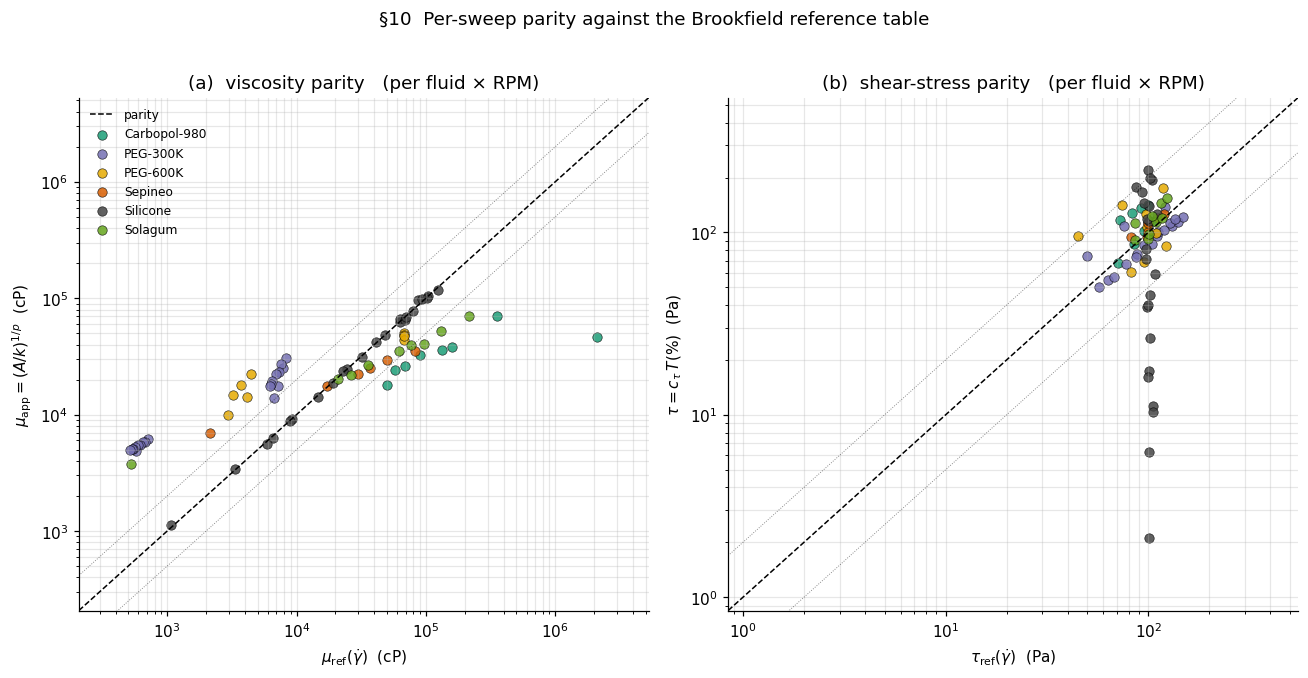

per-sweep parity points: 75

median |%| error by family (μ and τ):
               n  mu_med_abs_pct  tau_med_abs_pct
family                                           
Carbopol-980   8            68.4             25.9
PEG-300K      20           509.8             14.0
PEG-600K       9           237.1             28.8
Sepineo        6            36.7              6.1
Silicone      23             2.6             74.3
Solagum        9            48.4              7.5

--- full per-sweep parity table ---
      family conc  rpm  gamma_dot  mu_ref_cP  mu_app_cP  mu_pct_err  tau_ref_Pa  tau_Pa  tau_pct_err       ref_source
Carbopol-980 0.3%  0.4        0.8   9.05e+04   3.25e+04       -64.1        72.4     118         62.5            exact
Carbopol-980 0.3%  0.6        1.2   6.91e+04    2.6e+04       -62.4          83     128         54.2            exact
Carbopol-980 0.3%  0.8        1.6   5.75e+04   2.42e+04       -57.9          92     136         47.5           interp
Carbopol-980 0.3%    1  

In [16]:
# Build a per-sweep parity frame from `amps` (one row per fluid × RPM).
# `amps` already has mu_true_cP (which is now the Brookfield-interpolated ref);
# drop ambiguous duplicates before merging in extra columns from raw_long.
parity = amps.copy()
parity = parity.merge(raw_long[["fluid_id","rpm","ref_source"]]
                              .drop_duplicates(["fluid_id","rpm"]),
                      on=["fluid_id","rpm"], how="left")
parity = parity.rename(columns={"mu_true_cP": "mu_ref_cP"})

# apparent viscosity from the cone-plate amplitude calibration
parity["mu_app_cP"] = (parity["A"] / SILICONE_K) ** (1.0/SILICONE_P)

# measured & reference shear stress at this exact γ̇
parity = parity.merge(stress_pts[["fluid_id","rpm","tau_Pa","tau_ref_Pa"]],
                       on=["fluid_id","rpm"], how="left")
parity = parity.dropna(subset=["mu_ref_cP","mu_app_cP"])

# error metrics
parity["mu_pct_err"]  = 100*(parity["mu_app_cP"]-parity["mu_ref_cP"])/parity["mu_ref_cP"]
parity["tau_pct_err"] = 100*(parity["tau_Pa"]   -parity["tau_ref_Pa"])/parity["tau_ref_Pa"]

# --------------------------- plot two parities ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.0, 6.0))

def _parity_panel(ax, x, y, title, xl, yl):
    lo = float(np.nanmin([x.min(), y.min()])) * 0.4
    hi = float(np.nanmax([x.max(), y.max()])) * 2.5
    line = np.geomspace(lo, hi, 50)
    ax.plot(line, line,     "k--", lw=1.0, label="parity")
    ax.plot(line, 2*line,   "k:",  lw=0.6, alpha=0.5)
    ax.plot(line, 0.5*line, "k:",  lw=0.6, alpha=0.5)
    for fam, g in parity.groupby("family"):
        col = FAMILY_COLOR.get(fam, "#444")
        ax.scatter(g[x.name], g[y.name], s=38, color=col,
                   edgecolor="k", linewidth=0.4, alpha=0.85, label=fam)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

_parity_panel(axes[0], parity["mu_ref_cP"], parity["mu_app_cP"],
              "(a)  viscosity parity   (per fluid × RPM)",
              r"$\mu_{\mathrm{ref}}(\dot\gamma)$  (cP)",
              r"$\mu_{\mathrm{app}}=(A/k)^{1/p}$  (cP)")

valid_tau = parity.dropna(subset=["tau_Pa","tau_ref_Pa"])
if not valid_tau.empty:
    _parity_panel(axes[1], valid_tau["tau_ref_Pa"], valid_tau["tau_Pa"],
                  "(b)  shear-stress parity   (per fluid × RPM)",
                  r"$\tau_{\mathrm{ref}}(\dot\gamma)$  (Pa)",
                  r"$\tau = c_\tau\,T(\%)$  (Pa)")

# de-duplicate legend entries
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[0].legend(uniq.values(), uniq.keys(), fontsize=8,
               frameon=False, loc="upper left")
fig.suptitle("§10  Per-sweep parity against the Brookfield reference table",
             fontsize=12, y=1.02)
fig.tight_layout()
save_fig(fig, "10_parity_per_sweep"); plt.show()

# ------------------------------ summary -----------------------------------
print(f"per-sweep parity points: {len(parity)}")
print("\nmedian |%| error by family (μ and τ):")
err_summary = (parity.assign(abs_mu=parity["mu_pct_err"].abs(),
                              abs_tau=parity["tau_pct_err"].abs())
                      .groupby("family")
                      .agg(n=("rpm","count"),
                           mu_med_abs_pct =("abs_mu","median"),
                           tau_med_abs_pct=("abs_tau","median"))
                      .round(1))
print(err_summary.to_string())

with pd.option_context("display.float_format","{:.3g}".format,"display.max_rows",None):
    show = (parity[["family","conc","rpm","gamma_dot","mu_ref_cP","mu_app_cP",
                    "mu_pct_err","tau_ref_Pa","tau_Pa","tau_pct_err","ref_source"]]
              .sort_values(["family","conc","rpm"]))
    print("\n--- full per-sweep parity table ---")
    print(show.to_string(index=False))

## 11. The unified `predict_rheology()` interface

A single function consumes any combination of height, torque, and RPM data and returns
a consistent dict describing the fluid:

* **single-RPM input** → Newtonian estimate ($n \equiv 1$, single $\mu$);
* **multi-RPM input** → power-law $\tau = K\,\dot\gamma^{\,n}$, with $n$, $K$,
  $\eta_{\mathrm{app}}(\dot\gamma)$ callable, and an automatic classification of the
  flow regime (Newtonian / shear-thinning / shear-thickening).

This is the function any downstream code (control loop, real-time UI, batch analysis)
should call.


In [17]:
def predict_rheology(h_mm, torque_pct, rpm, *,
                     hc=None, k=None, p=None,
                     thinning_thr=0.95, thickening_thr=1.05):
    """Unified Newtonian / power-law rheology estimator.

    Single-RPM call:
        h_mm, torque_pct : 1-D arrays  (one sweep)
        rpm              : scalar
    Multi-RPM call:
        h_mm, torque_pct : list of 1-D arrays
        rpm              : list/array of scalars

    Returns dict with keys:
        mode         'newtonian' | 'powerlaw'
        regime       'Newtonian' | 'shear-thinning' | 'shear-thickening'
        n            flow-behaviour index
        K_Pas_n      consistency (Pa·s^n)
        mu_app       float (cP, Newtonian) or callable γ̇ -> η_app(cP) (power-law)
        tau          callable γ̇ -> τ(Pa)
        A_per_rpm    [(rpm, A), ...]
        R2_powerlaw  R² of log-log A vs γ̇
    """
    hc = H_C_UNIVERSAL if hc is None else hc
    k  = SILICONE_K    if k  is None else k
    p  = SILICONE_P    if p  is None else p

    # mode detection: multi-RPM iff h_mm is a sequence of sequences
    try:
        is_seq = (hasattr(h_mm, "__len__") and not isinstance(h_mm, (str, bytes, np.ndarray))
                  and hasattr(h_mm[0], "__len__") and not isinstance(h_mm[0], (str, bytes)))
    except (IndexError, TypeError):
        is_seq = False

    def _A(h, T, rpm_):
        fit = fit_drag(np.asarray(h, float), np.asarray(T, float)/float(rpm_), hc=hc)
        return fit["A"]

    if not is_seq:
        A = _A(h_mm, torque_pct, rpm)
        mu = float(amplitude_to_viscosity(np.array([A]), k=k, p=p)[0])
        K_Pas = mu * CP_TO_PAS
        return dict(mode="newtonian", regime="Newtonian", n=1.0, K_Pas_n=K_Pas,
                    mu_app=mu, tau=lambda g: K_Pas*np.asarray(g, float),
                    A_per_rpm=[(float(rpm), A)], R2_powerlaw=np.nan)

    A_pts = []
    for hh, tt, rr in zip(h_mm, torque_pct, rpm):
        A_pts.append((float(rr), _A(hh, tt, rr)))
    A_pts = [(r_, a_) for r_, a_ in A_pts if np.isfinite(a_) and a_ > 0]
    if len(A_pts) < 2:
        return dict(mode="powerlaw", regime="undetermined", n=np.nan,
                    K_Pas_n=np.nan, mu_app=lambda g: np.nan,
                    tau=lambda g: np.nan, A_per_rpm=A_pts, R2_powerlaw=np.nan)
    rpms_, As_ = map(np.array, zip(*A_pts))
    g_         = shear_rate(rpms_)
    pl         = fit_powerlaw(g_, As_)
    mu0        = float(amplitude_to_viscosity(np.array([As_[np.argmin(g_)]]), k=k, p=p)[0])
    g0         = float(g_.min())
    K_cP       = mu0 * g0**(1.0 - pl["n"])
    K_Pas      = K_cP * CP_TO_PAS
    n_         = pl["n"]
    if   n_ > thickening_thr: regime = "shear-thickening"
    elif n_ < thinning_thr:   regime = "shear-thinning"
    else:                     regime = "Newtonian"
    eta_cP = lambda g: K_cP * np.asarray(g, float)**(n_-1.0)
    tau_Pa = lambda g: K_Pas * np.asarray(g, float)**n_
    return dict(mode="powerlaw", regime=regime, n=n_, K_Pas_n=K_Pas,
                mu_app=eta_cP, tau=tau_Pa, A_per_rpm=A_pts,
                R2_powerlaw=pl["R2"])

# ---- demo: every fluid in the dataset --------------------------------------
demo_rows = []
for fid, sub in raw_long.groupby("fluid_id"):
    rpms = sorted(sub["rpm"].unique())
    if len(rpms) == 1:
        s = sub
        res = predict_rheology(s["h_mm"].values, s["T_pct"].values, rpms[0])
        eta = res["mu_app"]
    else:
        res = predict_rheology(
            [sub.loc[sub["rpm"] == r, "h_mm"].values   for r in rpms],
            [sub.loc[sub["rpm"] == r, "T_pct"].values for r in rpms],
            rpms)
        eta = res["mu_app"](shear_rate(np.median(rpms)))
    demo_rows.append({"fluid_id": fid, "n_rpms": len(rpms),
                      "regime": res["regime"], "n": res["n"],
                      "K_Pas^n": res["K_Pas_n"],
                      "η_app(at γ̇_mid)_cP": float(eta) if np.isscalar(eta) else float(eta)})

demo = pd.DataFrame(demo_rows).sort_values(["regime","fluid_id"]).reset_index(drop=True)
print(demo.to_string(index=False))
demo.to_csv(OUT_DIR / "predict_rheology_demo.csv", index=False)

         fluid_id  n_rpms         regime         n    K_Pas^n  η_app(at γ̇_mid)_cP
    PEG-600K|6.5%       1      Newtonian  1.000000  14.299173         14299.172567
       Sepineo|1%       1      Newtonian  1.000000   6.984733          6984.732664
     Sepineo|1.5%       1      Newtonian  1.000000  17.473376         17473.376295
  Silicone|100kcP       1      Newtonian  1.000000 117.399886        117399.885869
   Silicone|10kcP       1      Newtonian  1.000000   9.143295          9143.294620
 Silicone|12.5kcP       1      Newtonian  1.000000  14.269983         14269.982637
   Silicone|15kcP       1      Newtonian  1.000000  18.533722         18533.722362
    Silicone|1kcP       1      Newtonian  1.000000   1.119229          1119.229359
   Silicone|20kcP       1      Newtonian  1.000000  24.821338         24821.338075
   Silicone|25kcP       1      Newtonian  1.000000  23.680343         23680.343067
    Silicone|2kcP       1      Newtonian  1.000000   3.432139          3432.138893
   S

## 12. Conclusions and outputs

**Pipeline summary.** Automated descent data collected as $(h, T(\%), \mathrm{RPM})$
triples were converted into full $\tau(\dot\gamma)$ flow curves in four physics-based
steps: (i) a one-amplitude drag-profile fit, (ii) a universal-geometry calibration
yielding $h_c \approx 0.25$ mm, (iii) a silicone-oil amplitude-to-viscosity calibration
$A = k\,\mu^{\,p}$, and (iv) a multi-RPM power-law extension giving $(n, K)$ per fluid.
A first-principles cone-plate torque calibration ($M_{\mathrm{full}} = 7187$ dyne·cm
$\Rightarrow\,\tau = 1.99\cdot T(\%)$ Pa) provides an *independent* stress axis that
cross-validates the entire calibration chain.

**Classification.** The fitted $n$ directly classifies each tested fluid:

* silicones — Newtonian by construction ($n \equiv 1$);
* PEG-300K 5 %, PEG-600K 10 % — mildly shear-thinning ($n \approx 0.5$–0.6);
* Sepineo 2 %, Solagum 2 % — strongly shear-thinning gels ($n \approx 0.15$–0.33);
* Solagum 3 %, Carbopol-980 0.3 %–0.4 % — yield-stress-dominated ($n \to 0$).

No shear-thickening fluid was present in the current dataset; the same pipeline would
report any such sample as $n > 1$ without modification.

**Artefacts written to `outputs_pipeline/`:**

| file                          | content                                            |
|-------------------------------|----------------------------------------------------|
| `amplitudes.csv`              | per (fluid, RPM) amplitude fit (A, B, R²)          |
| `flow_curves.csv`             | per fluid (n, K, μ_app, regime)                    |
| `stress_measurements.csv`     | per (fluid, RPM) τ from physical torque calibration|
| `predict_rheology_demo.csv`   | result of the unified predictor on every fluid     |

**Figures (in `figures_pipeline/`):**
`05_hc_distribution.png`, `06_silicone_calibration.png`,
`07_amplitude_flow_curves.png`, `09_master_rheogram.png`, `10_parity.png`.

**Use of the predictor.** Any future measurement — Newtonian or not, single- or
multi-RPM — is processed by a single function call:

```python
result = predict_rheology(h_mm, torque_pct, rpm)
print(result["regime"], result["n"], result["K_Pas_n"])
tau_at_10 = result["tau"](10.0)        # Pa at γ̇ = 10 s⁻¹
```

That is the smallest possible API that captures the full content of this study.


## 13. Per-family rheograms — measurement vs. prediction

A small-multiples view that breaks the master rheogram of §9 apart by fluid family.
Each panel shows, *for one family only*:

* **filled circles** — measured $(\dot\gamma,\tau)$ from the instrument
  ($\tau = c_\tau\,T(\%)$), coloured by concentration / grade;
* **solid line** — the predicted rheology produced by `predict_rheology()` for the
  same fluid (Newtonian for single-RPM samples, power-law $\tau = K\,\dot\gamma^{n}$
  for multi-RPM samples), drawn over the measured shear-rate window and dotted just
  beyond it;
* **open stars** — the Brookfield reference points $(\dot\gamma, \tau_{\mathrm{ref}})$
  from `Polymers/Label_viscosity.csv` for the same `(family, conc)`, as an
  independent ground truth.

This is the cleanest visual test of the whole pipeline: if the solid line passes through
both the filled circles (instrument) and the open stars (Brookfield), then the fitted
flow curve correctly describes that fluid family.


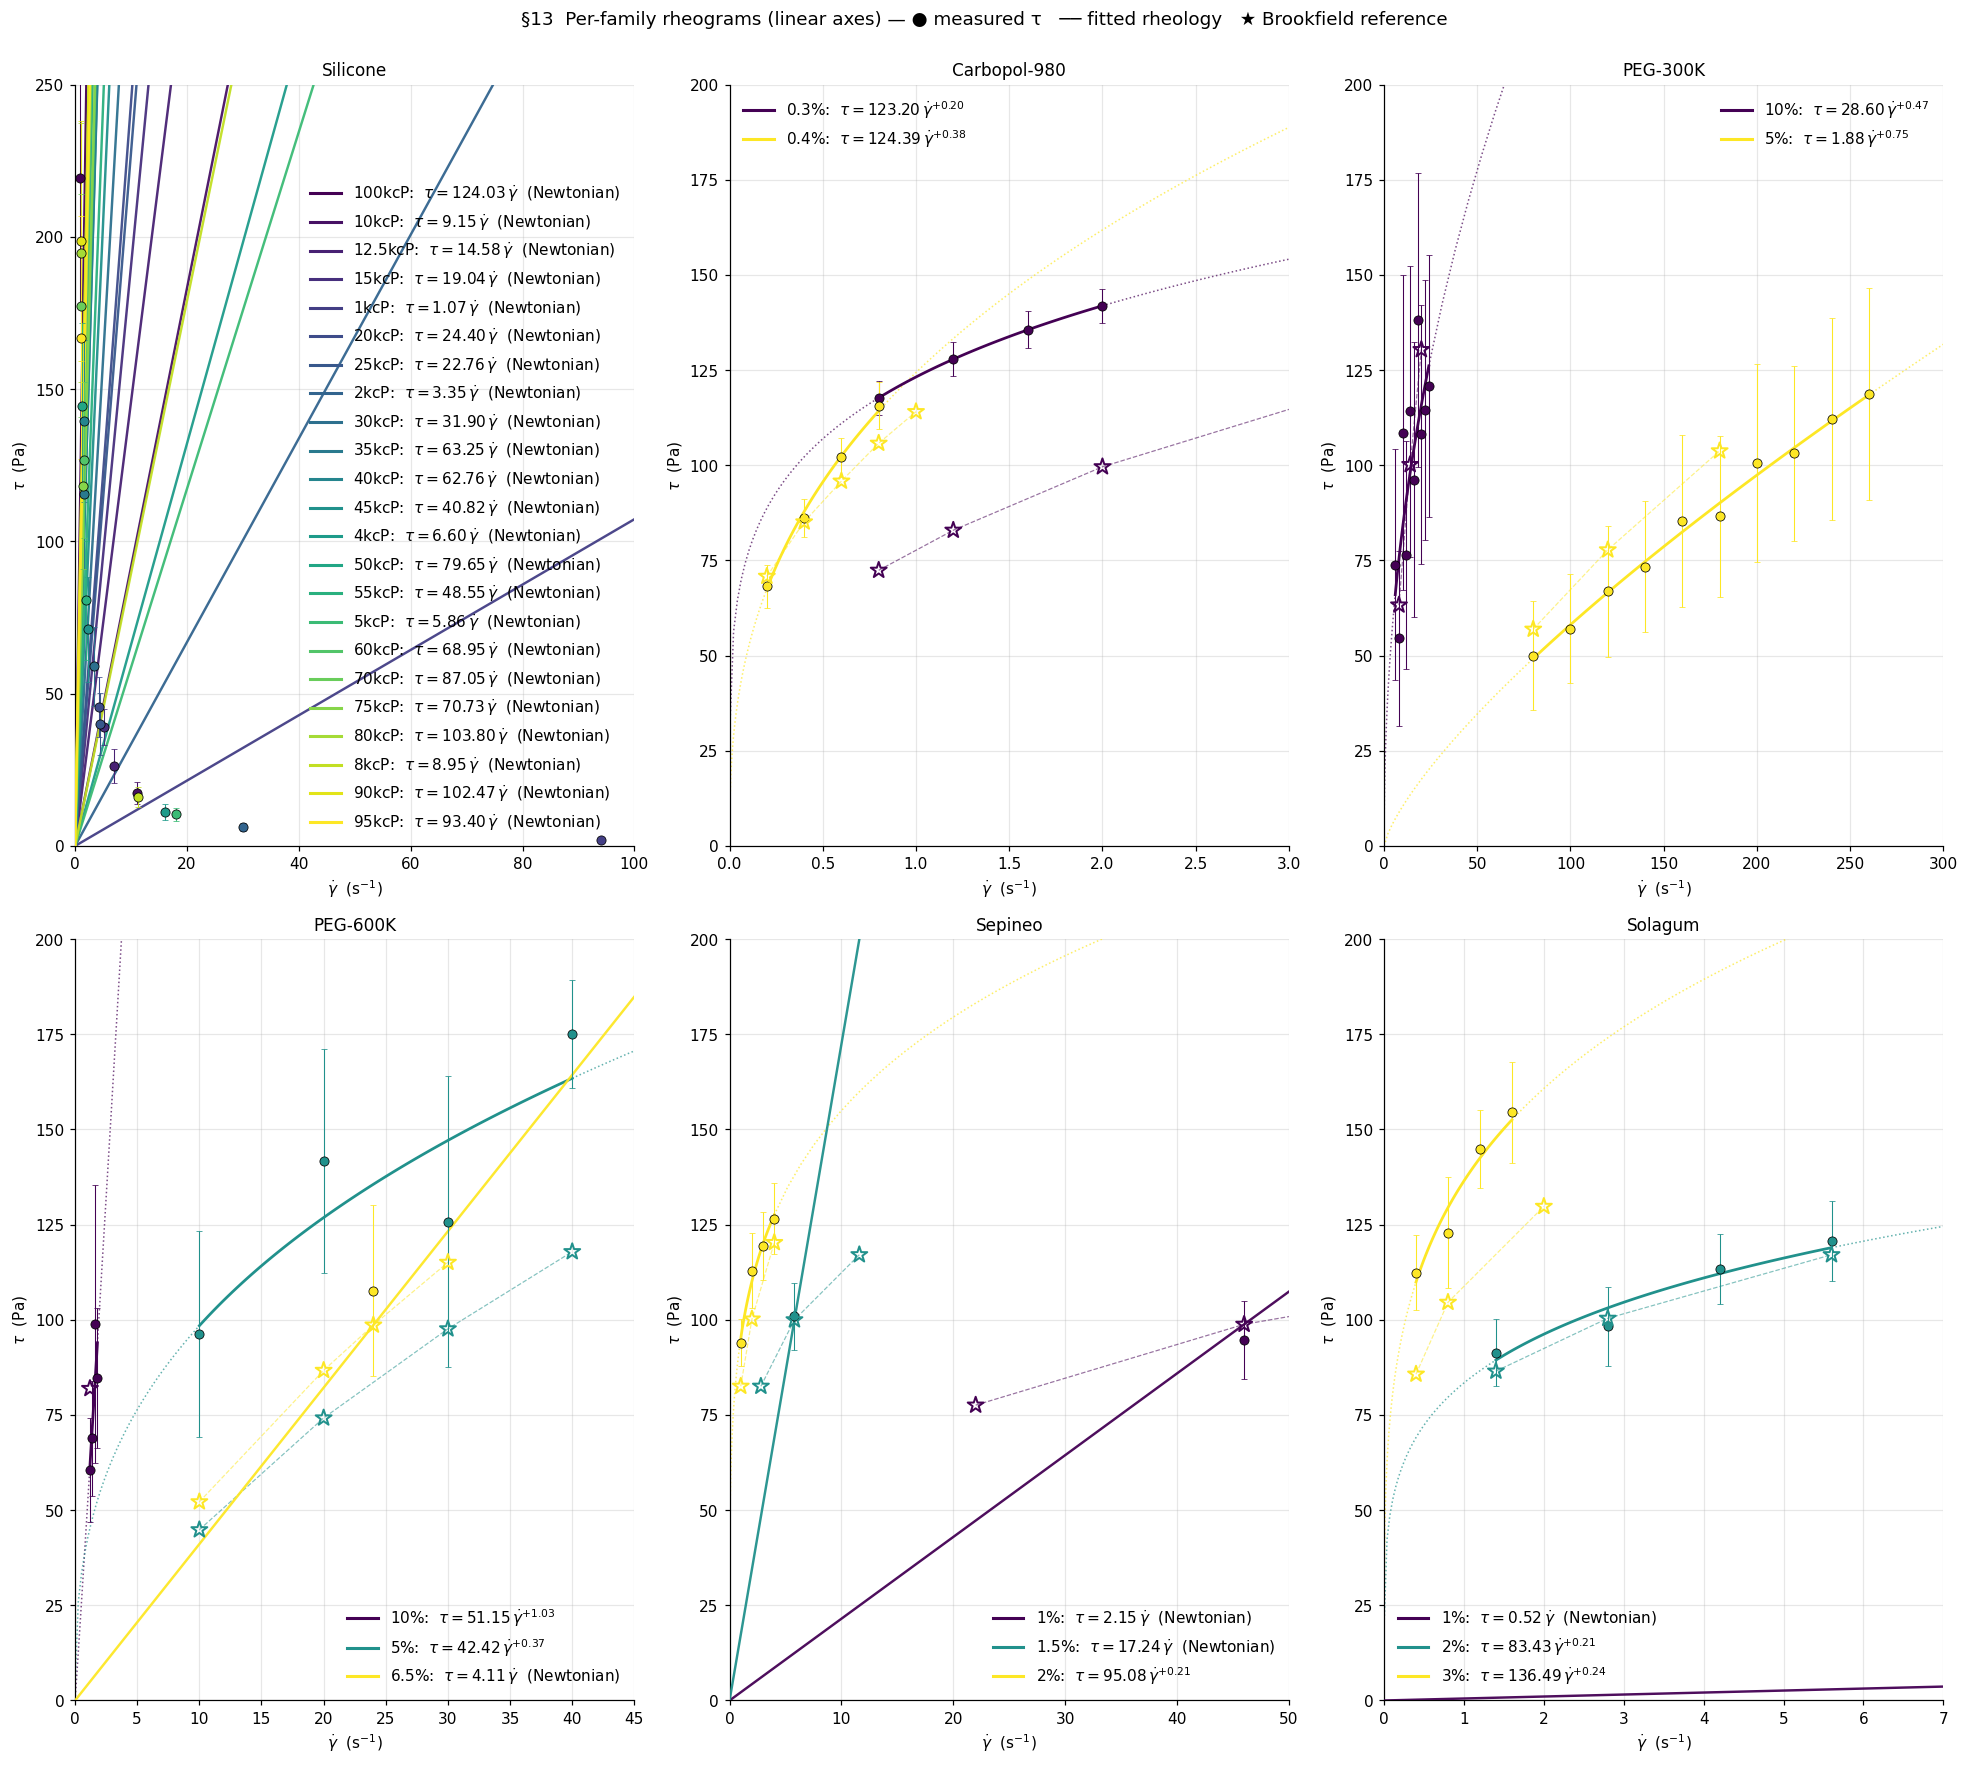

In [33]:
# --- §13  per-family rheogram panels --------------------------------------
# One subplot per fluid family on LINEAR axes.  Each subplot has its own
# x- and y-limits (set per family below).  For every fluid we draw:
#   ● instrument-measured (γ̇, τ) points,
#   ── a fitted rheology line (power-law for ≥2 RPMs, Newtonian otherwise),
#   ★ Brookfield reference points for the same (family, conc).
# Each fitted line is annotated with the corresponding equation.

def _fit_powerlaw_tau(gd, tau):
    """Linear log-log regression of τ vs γ̇  ->  (K, n, R²)."""
    gd = np.asarray(gd, float); tau = np.asarray(tau, float)
    m = np.isfinite(gd) & np.isfinite(tau) & (gd > 0) & (tau > 0)
    gd, tau = gd[m], tau[m]
    if len(gd) < 2: return None
    res = stats.linregress(np.log(gd), np.log(tau))
    return dict(K=float(np.exp(res.intercept)), n=float(res.slope),
                R2=float(res.rvalue**2), n_pts=int(len(gd)))

def _fmt_powerlaw_eq(tag, K, n):
    """Format τ = K·γ̇^n into a compact label string."""
    return rf"{tag}:  $\tau = {K:.2f}\,\dot\gamma^{{{n:+.2f}}}$"

def _fmt_newtonian_eq(tag, mu_pas):
    """Format τ = μ·γ̇ (Newtonian) into a compact label string."""
    return rf"{tag}:  $\tau = {mu_pas:.2f}\,\dot\gamma$  (Newtonian)"

# per-family axis limits — tuned to the data window in each panel
FAM_LIMITS = {
    "Silicone"    : dict(xlim=(0,  100), ylim=(0, 250)),
    "Carbopol-980": dict(xlim=(0,    3), ylim=(0, 200)),
    "PEG-300K"    : dict(xlim=(0,  300), ylim=(0, 200)),
    "PEG-600K"    : dict(xlim=(0,   45), ylim=(0, 200)),
    "Sepineo"     : dict(xlim=(0,   50), ylim=(0, 200)),
    "Solagum"     : dict(xlim=(0,    7), ylim=(0, 200)),
}

families = [f for f in
            ["Silicone","Carbopol-980","PEG-300K","PEG-600K","Sepineo","Solagum"]
            if f in stress_pts["family"].unique()]
ncols = 3
nrows = int(np.ceil(len(families) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.0*ncols, 8.0*nrows), squeeze=False)

for ax, fam in zip(axes.ravel(), families):
    fam_meas  = stress_pts[stress_pts["family"] == fam]
    fam_ref   = ref_long  [ref_long  ["family"] == fam]
    fluid_ids = sorted(fam_meas["fluid_id"].unique())
    cmap      = plt.get_cmap("viridis", max(len(fluid_ids), 2))

    lim = FAM_LIMITS.get(fam, dict(xlim=(0, None), ylim=(0, None)))
    x_lo, x_hi = lim["xlim"]
    y_lo, y_hi = lim["ylim"]

    eq_labels = []   # one equation per fluid, collected for the legend

    for i, fid in enumerate(fluid_ids):
        col  = cmap(i / max(len(fluid_ids)-1, 1))
        m    = fam_meas[fam_meas["fluid_id"] == fid].sort_values("gamma_dot")
        conc = m["conc"].iloc[0]
        tag  = fid.split("|")[-1]

        # (a) measured (γ̇, τ) points from instrument torque
        ax.errorbar(m["gamma_dot"], m["tau_Pa"], yerr=m["tau_err_Pa"],
                    fmt="o", color=col, markersize=6,
                    markeredgecolor="k", markeredgewidth=0.5,
                    ecolor=col, elinewidth=0.7, capsize=2,
                    zorder=4)

        # (b) fitted rheology line — power-law if ≥2 RPMs, else Newtonian
        g_lo = float(m["gamma_dot"].min()); g_hi = float(m["gamma_dot"].max())
        x_plot_lo = max(1e-3, x_lo if x_lo is not None else g_lo)
        x_plot_hi = (x_hi if x_hi is not None else g_hi)

        fit = _fit_powerlaw_tau(m["gamma_dot"].values, m["tau_Pa"].values)
        if fit is not None:
            K, n_ = fit["K"], fit["n"]
            eq_labels.append((col, _fmt_powerlaw_eq(tag, K, n_)))
            # solid inside measured range
            g_in  = np.linspace(g_lo, g_hi, 80)
            ax.plot(g_in, K*g_in**n_, "-", color=col, lw=1.8, zorder=3)
            # dotted extension to the visible axis limits
            if g_lo > x_plot_lo:
                g_pre = np.linspace(x_plot_lo, g_lo, 40)
                ax.plot(g_pre, K*g_pre**n_, ":", color=col, lw=1.0, alpha=0.7)
            if g_hi < x_plot_hi:
                g_post = np.linspace(g_hi, x_plot_hi, 40)
                ax.plot(g_post, K*g_post**n_, ":", color=col, lw=1.0, alpha=0.7)
        else:
            mu_pas = float(m["mu_true_cP"].iloc[0]) * CP_TO_PAS
            if np.isfinite(mu_pas) and mu_pas > 0:
                g_line = np.linspace(x_plot_lo, x_plot_hi, 80)
                ax.plot(g_line, mu_pas*g_line, "-", color=col, lw=1.6,
                        alpha=0.95, zorder=3)
                eq_labels.append((col, _fmt_newtonian_eq(tag, mu_pas)))
            else:
                eq_labels.append((col, tag))

        # (c) Brookfield reference stars for this (family, conc)
        if conc is not None:
            ref = fam_ref[fam_ref["conc"] == conc].sort_values("gd_ref")
            if not ref.empty:
                ax.plot(ref["gd_ref"], ref["tau_ref_Pa"], color=col,
                        lw=0.8, ls="--", alpha=0.55, zorder=2)
                ax.scatter(ref["gd_ref"], ref["tau_ref_Pa"], marker="*",
                           s=120, facecolor="none", edgecolor=col,
                           linewidth=1.3, zorder=5)

    # ---- linear axes with per-family limits --------------------------------
    ax.set_xscale("linear"); ax.set_yscale("linear")
    ax.set_xlim(x_lo, x_hi); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(r"$\dot\gamma$  (s$^{-1}$)")
    ax.set_ylabel(r"$\tau$  (Pa)")
    ax.set_title(f"{fam}", fontsize=11)
    ax.grid(True, which="both", alpha=0.3)

    # ---- legend showing the rheology equation for each fluid --------------
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=c, lw=2) for c, _ in eq_labels]
    ax.legend(handles, [lbl for _, lbl in eq_labels],
              fontsize=10, frameon=False, loc="best", ncol=1)

# hide unused axes
for ax in axes.ravel()[len(families):]:
    ax.set_visible(False)

fig.suptitle("§13  Per-family rheograms (linear axes) — "
             "● measured τ   ── fitted rheology   ★ Brookfield reference",
             fontsize=12, y=1.00)
fig.tight_layout()
save_fig(fig, "13_per_family_rheograms"); plt.show()